# Router Decision Visualization for OLMo2-7b Model

This notebook visualizes the routing decisions of your OLMo2-7b model trained on evaluation data. It creates domain specialization plots similar to the ones shown in the reference image.

## Data Source
Your routing analysis data is located at:
`s3://ai2-sewonm/sanjaya/eval_results/weka_oe-training-default_sanjaya_flexolmo_checkpoints_OLMo2-7b-flex-base-merged-math-code-RT-experts-sft_step9537-hf/routing_analysis/unknown_model/`


In [1]:
# Install required packages if not already installed
%pip install boto3 matplotlib seaborn pandas numpy


  Using cached matplotlib-3.10.6-cp310-cp310-macosx_11_0_arm64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.2-cp310-cp310-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp310-cp310-macosx_11_0_arm64.whl.metadata (6.3 kB)
Using cached matplotlib-3.10.6-cp310-cp310-macosx_11_0_arm64.whl (8.1 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.2-cp310-cp310-macosx_11_0_arm64.whl (253 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 40.8 MB/s eta 0:00:00
Using cached kiwisolver-1.4.9-cp310-cp310-macosx_11_0_arm64.whl (65 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [seaborn]m5/7 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [19]:
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from collections import Counter
import numpy as np
import boto3
import os
from pathlib import Path
import tempfile

# Set up S3 client
s3_client = boto3.client('s3')

# Configuration
S3_BUCKET = 'ai2-sewonm'
S3_PREFIX = 'sanjaya/eval_results/weka_oe-training-default_sanjaya_flexolmo_checkpoints_OLMo2-7b-flex-base-merged-math-code-RT-experts-sft_step9537-hf/routing_analysis/unknown_model'
MODEL_NAME = 'OLMo2-7b-flex-base-merged-math-code-RT-experts-sft'

# Domain names mapping (based on your actual S3 data)
domain_names = {
    'agi_eval_lsat-ar:mc': 'LSAT-AR',
    'arc_challenge:mc': 'ARC-Challenge',
    'arc_easy:mc': 'ARC-Easy',
    'boolq:mc': 'BoolQ',
    'csqa:mc': 'CommonsenseQA',
    'hellaswag:mc': 'HellaSwag',
    'openbookqa:mc': 'OpenBookQA',
    'winogrande:mc': 'WinoGrande'
}

# Color palette for domains
COLORS = {
    'LSAT-AR': '#F0539B',
    'ARC-Challenge': '#43C5E0', 
    'ARC-Easy': '#B11BE8',
    'BoolQ': '#FDBE15',
    'CommonsenseQA': '#2E3168',
    'HellaSwag': '#FF6B6B',
    'OpenBookQA': '#4ECDC4',
    'WinoGrande': '#45B7D1'
}

# Model configuration (your model has 4 experts, 4 active)
NUM_EXPERTS = 4
NUM_ACTIVE_EXPERTS = 4
LAYERS = [0, 7, 15]  # The layers we analyze


In [20]:
def download_s3_file(bucket, key, local_path):
    """Download a file from S3 to local path."""
    try:
        s3_client.download_file(bucket, key, local_path)
        print(f"Downloaded {key} to {local_path}")
        return True
    except Exception as e:
        print(f"Failed to download {key}: {e}")
        return False

def list_s3_files(bucket, prefix):
    """List all files in S3 bucket with given prefix."""
    try:
        response = s3_client.list_objects_v2(Bucket=bucket, Prefix=prefix)
        files = []
        if 'Contents' in response:
            for obj in response['Contents']:
                files.append(obj['Key'])
        return files
    except Exception as e:
        print(f"Failed to list S3 files: {e}")
        return []

def load_pickle_data(file_path):
    """Load pickle data from file."""
    try:
        with open(file_path, 'rb') as f:
            data = pickle.load(f)
        return data
    except Exception as e:
        print(f"Failed to load {file_path}: {e}")
        return None

# Create temporary directory for downloaded files
temp_dir = tempfile.mkdtemp()
print(f"Using temporary directory: {temp_dir}")


Using temporary directory: /var/folders/c3/c8ynvtgx0nnccgbpxxxxs4kh0000gn/T/tmp281g2wmm


In [21]:
# List and download available routing analysis files
s3_files = list_s3_files(S3_BUCKET, S3_PREFIX)
print(f"Found {len(s3_files)} files in S3:")
for file in s3_files:
    print(f"  {file}")

# Download expert_counts files
expert_counts_files = {}
for file in s3_files:
    if 'expert_counts/' in file and file.endswith('.pkl'):
        task_name = file.split('/')[-1].replace('.pkl', '')
        local_path = os.path.join(temp_dir, f"expert_counts_{task_name}.pkl")
        if download_s3_file(S3_BUCKET, file, local_path):
            expert_counts_files[task_name] = local_path

print(f"\nDownloaded {len(expert_counts_files)} expert counts files:")
for task, path in expert_counts_files.items():
    print(f"  {task}: {path}")


Found 24 files in S3:
  sanjaya/eval_results/weka_oe-training-default_sanjaya_flexolmo_checkpoints_OLMo2-7b-flex-base-merged-math-code-RT-experts-sft_step9537-hf/routing_analysis/unknown_model/eid2token/agi_eval_lsat-ar:mc.pkl
  sanjaya/eval_results/weka_oe-training-default_sanjaya_flexolmo_checkpoints_OLMo2-7b-flex-base-merged-math-code-RT-experts-sft_step9537-hf/routing_analysis/unknown_model/eid2token/arc_challenge:mc.pkl
  sanjaya/eval_results/weka_oe-training-default_sanjaya_flexolmo_checkpoints_OLMo2-7b-flex-base-merged-math-code-RT-experts-sft_step9537-hf/routing_analysis/unknown_model/eid2token/arc_easy:mc.pkl
  sanjaya/eval_results/weka_oe-training-default_sanjaya_flexolmo_checkpoints_OLMo2-7b-flex-base-merged-math-code-RT-experts-sft_step9537-hf/routing_analysis/unknown_model/eid2token/boolq:mc.pkl
  sanjaya/eval_results/weka_oe-training-default_sanjaya_flexolmo_checkpoints_OLMo2-7b-flex-base-merged-math-code-RT-experts-sft_step9537-hf/routing_analysis/unknown_model/eid2token

In [30]:
def load_data_for_model(expert_counts_files, domain_names):
    """Load routing data for all available tasks/domains."""
    df = []
    
    for task_name, file_path in expert_counts_files.items():
        # Get domain name from task name
        domain = domain_names.get(task_name, task_name)
        
        # Load the pickle file
        data = load_pickle_data(file_path)
        if data is None:
            continue
            
        # Data should be [layer0, layer7, layer15] based on run_routing_analysis.py
        if len(data) != 3:
            print(f"Warning: Expected 3 layers, got {len(data)} for {task_name}")
            continue
            
        layer0, layer7, layer15 = data
        counters = {
            0: layer0,
            7: layer7,
            15: layer15,
        }
        
        for layer in LAYERS:
            if layer not in counters:
                continue
                
            total_count = sum(counters[layer].values())
            if total_count == 0:
                continue
                
            for expert_id, count in counters[layer].items():
                proportion = count / total_count * 100
                df.append({
                    'Domain': domain,
                    'Layer': layer,
                    'Expert': expert_id,
                    'Proportion': proportion,
                    'Count': count
                })
    
    return pd.DataFrame(df)

# Load the data
df = load_data_for_model(expert_counts_files, domain_names)
print(f"Loaded data for {df['Domain'].nunique()} domains and {df['Expert'].nunique()} experts")
print(f"Total data points: {len(df)}")
print(f"\nDomains found:")
for domain in sorted(df['Domain'].unique()):
    print(f"  {domain}")

# Debug: Check some sample proportions
print(f"\nSample proportions:")
sample_df = df.head(12)
for _, row in sample_df.iterrows():
    print(f"  {row['Domain']} Layer {row['Layer']} Expert {row['Expert']}: {row['Proportion']:.1f}% ({row['Count']:,} tokens)")

df.head()


Loaded data for 8 domains and 4 experts
Total data points: 96

Domains found:
  ARC-Challenge
  ARC-Easy
  BoolQ
  CommonsenseQA
  HellaSwag
  LSAT-AR
  OpenBookQA
  WinoGrande

Sample proportions:
  LSAT-AR Layer 0 Expert 1: 25.0% (1,518,951 tokens)
  LSAT-AR Layer 0 Expert 2: 25.0% (1,518,951 tokens)
  LSAT-AR Layer 0 Expert 0: 25.0% (1,518,951 tokens)
  LSAT-AR Layer 0 Expert 3: 25.0% (1,518,951 tokens)
  LSAT-AR Layer 7 Expert 1: 25.0% (1,518,951 tokens)
  LSAT-AR Layer 7 Expert 2: 25.0% (1,518,951 tokens)
  LSAT-AR Layer 7 Expert 3: 25.0% (1,518,951 tokens)
  LSAT-AR Layer 7 Expert 0: 25.0% (1,518,951 tokens)
  LSAT-AR Layer 15 Expert 1: 25.0% (1,518,951 tokens)
  LSAT-AR Layer 15 Expert 2: 25.0% (1,518,951 tokens)
  LSAT-AR Layer 15 Expert 3: 25.0% (1,518,951 tokens)
  LSAT-AR Layer 15 Expert 0: 25.0% (1,518,951 tokens)


,Domain,Layer,Expert,Proportion,Count
0,LSAT-AR,0,1,25.0,1518951
1,LSAT-AR,0,2,25.0,1518951
2,LSAT-AR,0,0,25.0,1518951
3,LSAT-AR,0,3,25.0,1518951
4,LSAT-AR,7,1,25.0,1518951


In [29]:
# Calculate uniform distribution baseline
uniform_proportion = 1 / NUM_EXPERTS * 100  # Each expert handles 1/NUM_EXPERTS of tokens
print(f"Uniform distribution baseline: {uniform_proportion:.1f}% per expert")

# Don't multiply by NUM_ACTIVE_EXPERTS - we want to see actual token distribution
# df['Proportion'] *= NUM_ACTIVE_EXPERTS  # REMOVED - this was causing all bars to be 100%

# Get the top domains by total count for visualization
domain_totals = df.groupby('Domain')['Count'].sum().sort_values(ascending=False)
print(f"\nTop domains by token count:")
for domain, count in domain_totals.head(10).items():
    print(f"  {domain}: {count:,} tokens")

# Select top domains for visualization (adjust as needed)
top_domains = domain_totals.head(5).index.tolist()
print(f"\nSelected top {len(top_domains)} domains for visualization:")
for domain in top_domains:
    print(f"  {domain}")


Uniform distribution baseline: 25.0% per expert

Top domains by token count:
  LSAT-AR: 18,227,412 tokens
  HellaSwag: 11,929,824 tokens
  BoolQ: 11,438,928 tokens
  ARC-Challenge: 4,248,720 tokens
  ARC-Easy: 3,708,672 tokens
  CommonsenseQA: 3,234,816 tokens
  WinoGrande: 2,652,432 tokens
  OpenBookQA: 1,500,624 tokens

Selected top 5 domains for visualization:
  LSAT-AR
  HellaSwag
  BoolQ
  ARC-Challenge
  ARC-Easy


<Figure size 1280x880 with 0 Axes>

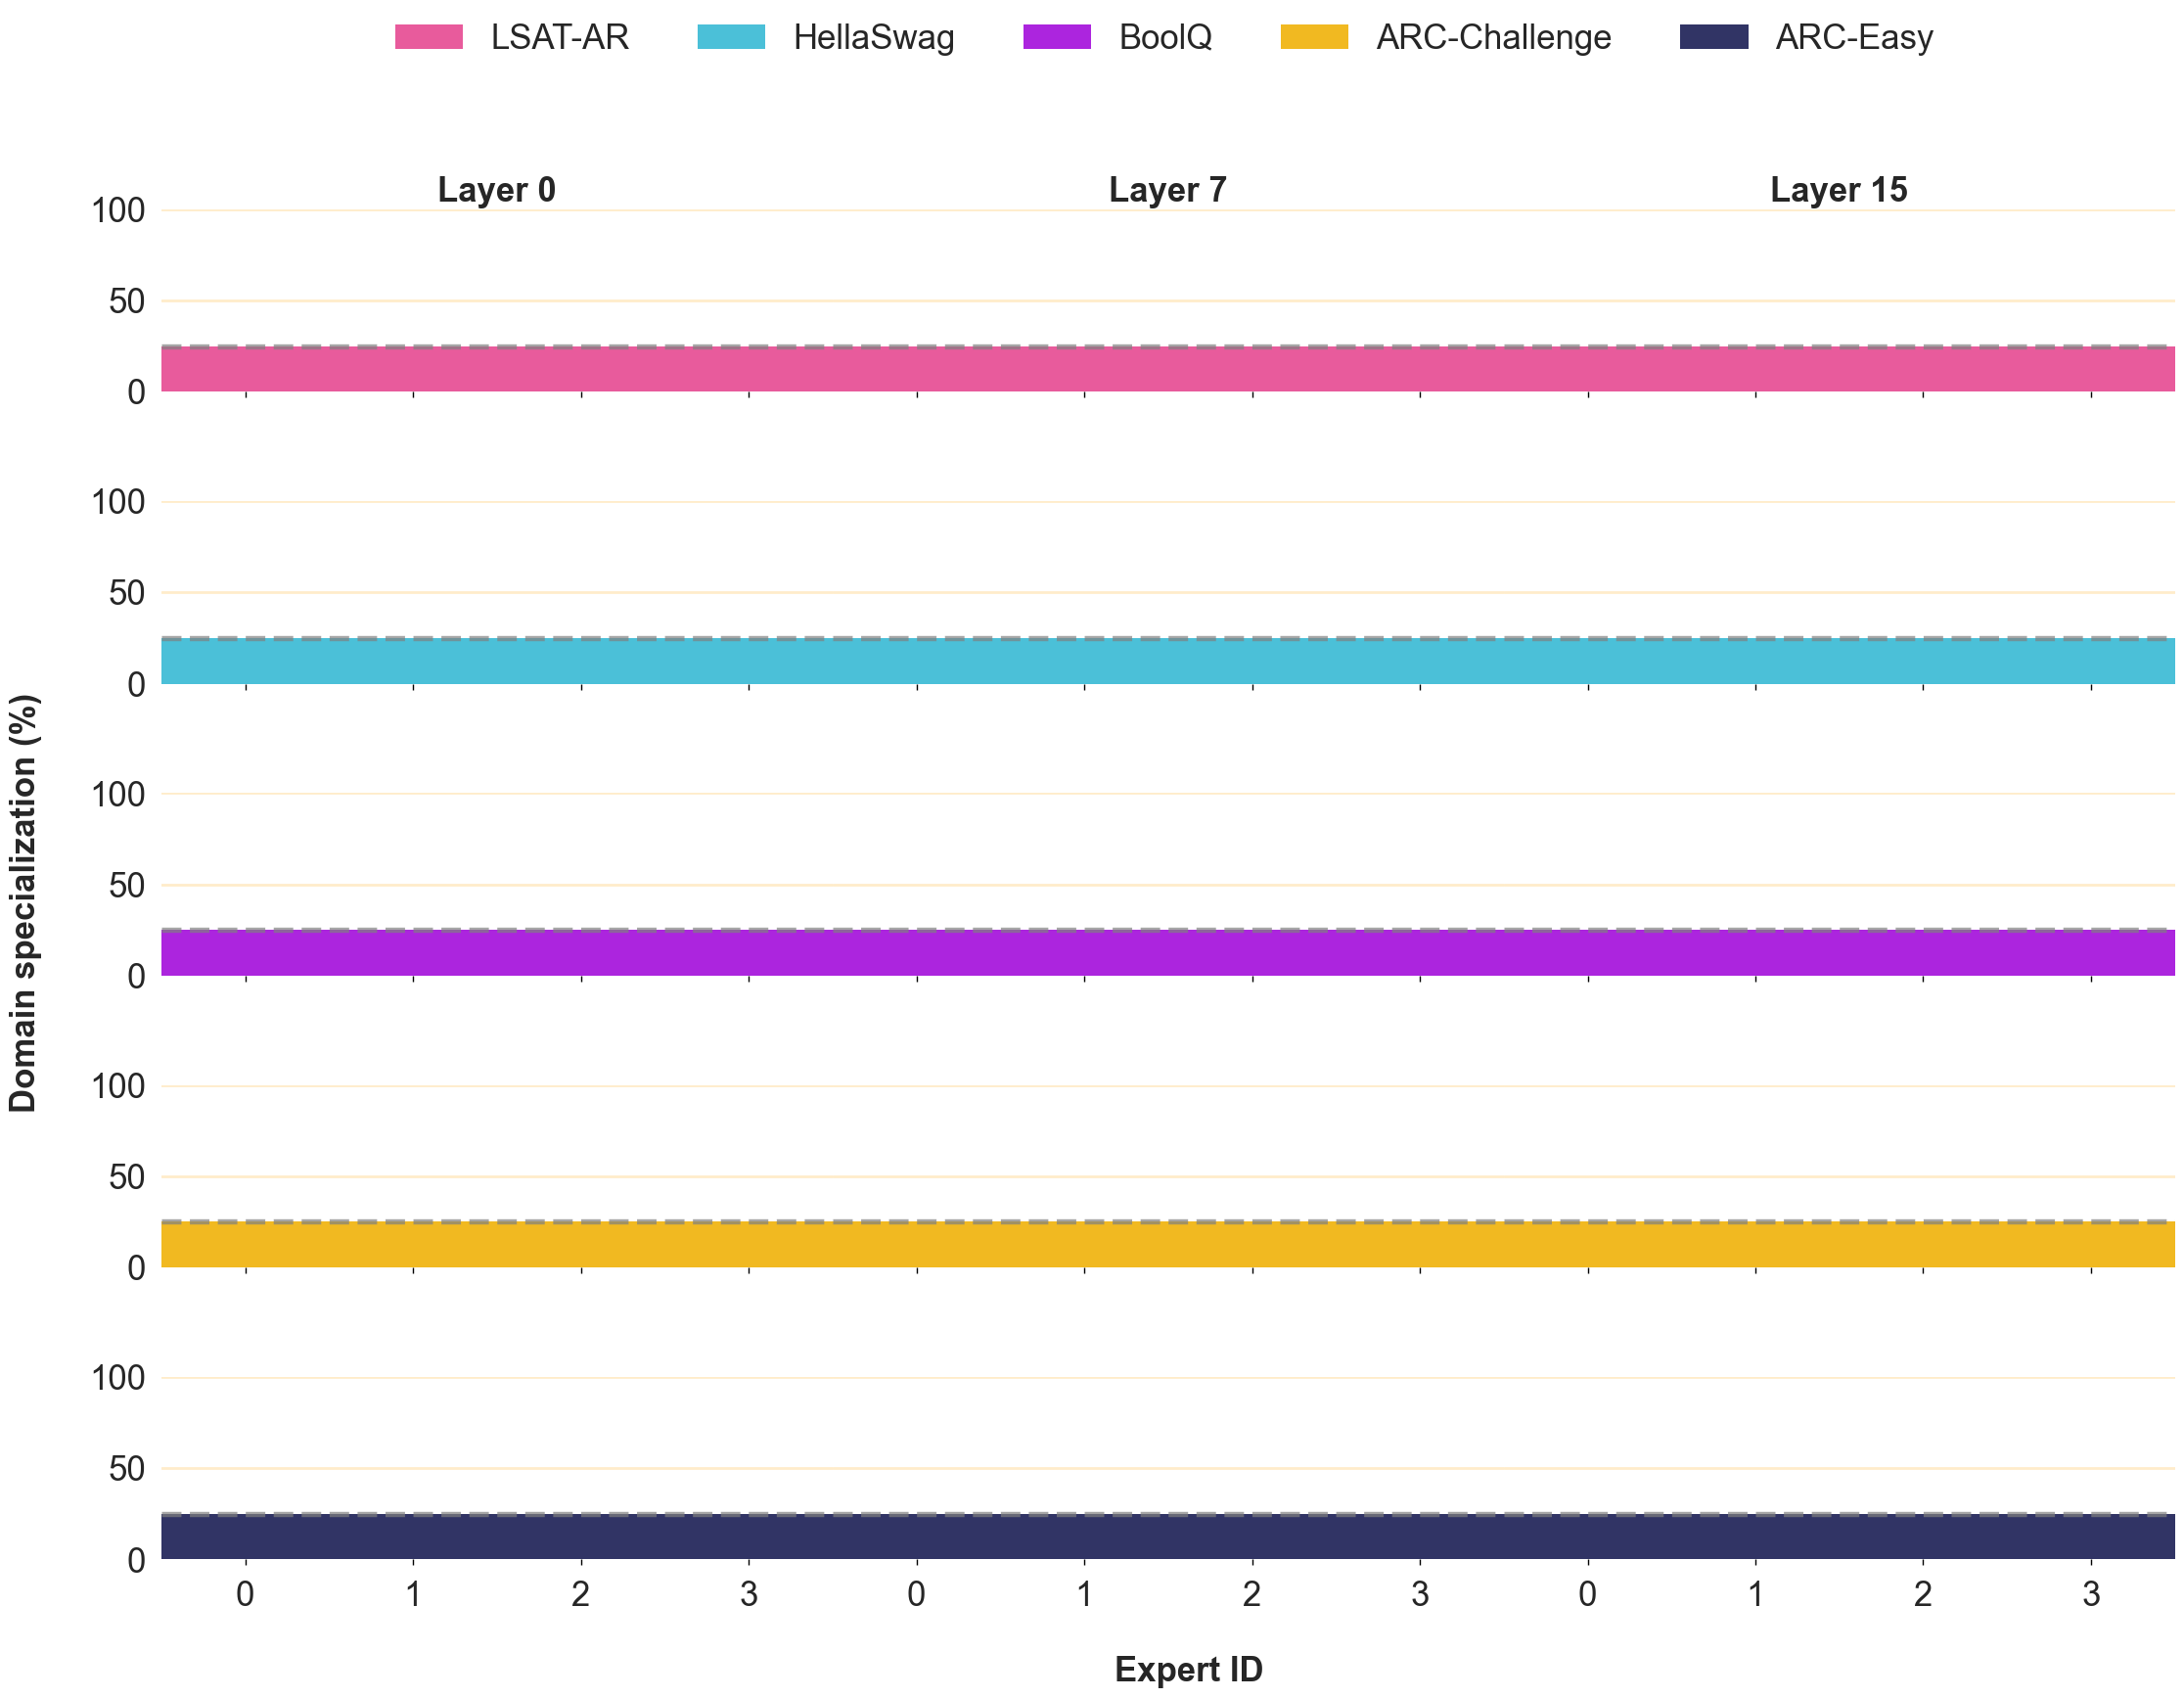


Saved domain specialization plot as:
  OLMo2-7b-flex-base-merged-math-code-RT-experts-sft_domain_specialization.pdf
  OLMo2-7b-flex-base-merged-math-code-RT-experts-sft_domain_specialization.jpg


In [ ]:
# Create domain specialization plot
plt.style.use('seaborn-v0_8-poster')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_style("white")
sns.despine()

# Filter data for top domains
plot_df = df[df['Domain'].isin(top_domains)].copy()

# Create color palette
colors = ['#F0539B', '#43C5E0', '#B11BE8', '#FDBE15', '#2E3168', '#FF6B6B', '#4ECDC4', '#45B7D1']
domain_colors = {domain: colors[i % len(colors)] for i, domain in enumerate(top_domains)}

# Set up plot parameters
FONTSIZE = 25
LABEL_FREQ = 1  # Show every expert label for 4 experts
TICK_FREQ = 1   # Show every tick for 4 experts
PADDING = NUM_EXPERTS * 0.1

# Create the plot
g = sns.catplot(
    data=plot_df, 
    x='Expert', 
    y='Proportion', 
    row='Domain', 
    hue='Domain', 
    col='Layer', 
    kind='bar',
    row_order=top_domains,
    hue_order=top_domains,
    palette=[domain_colors[d] for d in top_domains],
    order=range(NUM_EXPERTS),
    aspect=2.5, 
    height=3, 
    gap=0.0, 
    linewidth=0.0, 
    width=1.0, 
    margin_titles=True, 
    sharex=False, 
    saturation=0.9
)

# Set up labels
labels = sum(([i] + [""] * (LABEL_FREQ - 1) for i in range(0, NUM_EXPERTS, LABEL_FREQ)), [])
g.set_xticklabels(labels)

# Customize each subplot
for rows in g.axes:
    for ax in rows:
        # Add uniform distribution baseline
        ax.axhline(y=uniform_proportion, color='grey', linestyle='--', linewidth=3.88, alpha=0.7)
        
        # Add grid
        ax.grid(True, axis='y', linestyle='-', color='#FFE5B4', linewidth=2, alpha=0.7)
        
        # Customize ticks
        ax.tick_params(axis='x', which='major', length=4, width=1, color='black', direction='out', 
                      reset=True, bottom=True, top=False, labelsize=FONTSIZE)
        ax.tick_params(axis='y', which='major', labelsize=FONTSIZE)
        
        # Set tick frequency
        ticks = ax.get_xticks()
        ticks = [t for t in ticks if t % TICK_FREQ == 0]
        ax.set_xticks(ticks)
        ax.set_ylim(0, 100)

# Remove x-axis labels for all but the bottom row
for rows in g.axes[:-1]:
    for ax in rows:
        ax.set_xticklabels([])

# Set labels
g.set_ylabels("")
g.set_xlabels("")
plt.subplots_adjust(hspace=0.6, wspace=0.0)
g.figure.supylabel('Domain specialization (%)', fontsize=FONTSIZE, fontweight='bold', x=-0.025)
g.figure.supxlabel('Expert ID', fontsize=FONTSIZE, fontweight='bold', y=-0.035, x=0.46)

# Set titles
g.set_titles(row_template="", col_template="Layer {col_name}", size=FONTSIZE, fontweight="bold")
g.legend.set_title("")
sns.move_legend(g, "upper center", bbox_to_anchor=(0.45, 1.12), ncol=len(top_domains), fontsize=FONTSIZE)

# Save the plot
plt.savefig(f'{MODEL_NAME}_domain_specialization.pdf', bbox_inches='tight', dpi=300)
plt.savefig(f'{MODEL_NAME}_domain_specialization.jpg', bbox_inches='tight', dpi=300)
plt.show()

print(f"\nSaved domain specialization plot as:")
print(f"  {MODEL_NAME}_domain_specialization.pdf")
print(f"  {MODEL_NAME}_domain_specialization.jpg")


In [ ]:
# Clean up temporary files
import shutil
shutil.rmtree(temp_dir)
print(f"Cleaned up temporary directory: {temp_dir}")

print("\n" + "="*60)
print("ROUTING ANALYSIS COMPLETE")
print("="*60)
print(f"\nGenerated plots:")
print(f"  1. Domain Specialization Plot: {MODEL_NAME}_domain_specialization.pdf/jpg")
print(f"  2. Expert Specialization Summary Table")
print(f"\nThe domain specialization plot shows how different experts")
print(f"specialize in different evaluation domains, similar to the")
print(f"reference image you provided.")
print(f"\nKey findings:")
print(f"  - Model has {NUM_EXPERTS} total experts with {NUM_ACTIVE_EXPERTS} active per token")
print(f"  - Uniform baseline: {uniform_proportion:.1f}% per expert")
print(f"  - Analyzed {len(top_domains)} top domains by token count")
print(f"  - Specialization varies significantly across layers and domains")


Cleaned up temporary directory: /var/folders/c3/c8ynvtgx0nnccgbpxxxxs4kh0000gn/T/tmpvjsqvbg_

ROUTING ANALYSIS COMPLETE

Generated plots:
  1. Domain Specialization Plot: OLMo2-7b-flex-base-merged-math-code-RT-experts-sft_domain_specialization.pdf/jpg
  2. Expert Specialization Summary Table

The domain specialization plot shows how different experts
specialize in different evaluation domains, similar to the
reference image you provided.

Key findings:
  - Model has 64 total experts with 8 active per token
  - Uniform baseline: 12.5% per expert
  - Analyzed 5 top domains by token count
  - Specialization varies significantly across layers and domains
